<a href="https://colab.research.google.com/github/Malu-MDA/Exploratory-Data-Analysis/blob/main/Avalia%C3%A7%C3%A3o_Parcial_01_DataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CENTRO UNIVERSITÁRIO UNIMPACTA

# Trabalho Prático: Análise Exploratória de Dados (EDA) aplicada a Machine Learning

**Disciplina:** Exploratory Data Analysis (EDA)  
**Data de Entrega:** 18/09/2026  

**Modalidade:** Trabalho em Dupla  
**Formato de Entrega:** Link do Google Colab (Público/Editor)

**Aluno(a):** Maria Luiza Moreira de Alcantara  


## 1. Carregamento e Inspeção Inicial

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Ambiente configurado com sucesso!")

Ambiente configurado com sucesso!


In [89]:
df = pd.read_csv("ml_models_dataset_sujo.csv")

df.head()

,model_id,training_hours,accuracy,loss,dataset_size_gb,learning_rate,hardware_type,gpu_temp_c,deployment_status
0,MOD-001,17.814093,0.786136,0.203600,50.0,0.1000,CPU Only,70.646791,Review
1,MOD-002,12.235972,0.913192,0.011323,50.0,0.0010,Unknown,74.226789,Review
2,MOD-003,11.511403,0.818686,0.187371,10.0,0.0100,NVIDIA V100,NaN,Approved
3,MOD-004,11.511524,0.732474,0.308688,NaN,0.0001,NVIDIA V100,65.229122,Rejected
4,MOD-005,30.830700,0.778067,0.217905,10.0,0.0010,NVIDIA A100,67.320739,Rejected


In [90]:
df_antes = df.copy()

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   model_id           500 non-null    object 
 1   training_hours     475 non-null    float64
 2   accuracy           485 non-null    float64
 3   loss               466 non-null    float64
 4   dataset_size_gb    477 non-null    float64
 5   learning_rate      500 non-null    float64
 6   hardware_type      475 non-null    object 
 7   gpu_temp_c         470 non-null    float64
 8   deployment_status  500 non-null    object 
dtypes: float64(6), object(3)
memory usage: 35.3+ KB


In [92]:
df.describe()

,training_hours,accuracy,loss,dataset_size_gb,learning_rate,gpu_temp_c
count,475.000000,485.000000,466.000000,477.000000,500.000000,470.000000
mean,15.000922,0.863662,0.140502,135.555556,0.013445,73.807635
std,8.243605,0.116910,0.122981,233.117247,0.028740,17.750822
min,0.516594,0.581871,-0.623958,10.000000,-0.010000,47.938941
25%,9.041368,0.801832,0.074478,10.000000,0.001000,66.037916
50%,13.623337,0.857169,0.150891,50.000000,0.001000,72.238882
75%,19.227121,0.911563,0.213822,100.000000,0.010000,77.828568
max,47.314213,1.700190,0.514701,1000.000000,0.100000,198.329539


In [93]:
nulos = df.isnull().sum()
percentual_nulos = (df.isnull().sum() / len(df)) * 100

pd.DataFrame({
    "Valores Nulos": nulos,
    "Percentual (%)": percentual_nulos
})

,Valores Nulos,Percentual (%)
model_id,0,0.0
training_hours,25,5.0
accuracy,15,3.0
loss,34,6.8
dataset_size_gb,23,4.6
learning_rate,0,0.0
hardware_type,25,5.0
gpu_temp_c,30,6.0
deployment_status,0,0.0


## 2. Limpeza e Tratamento de Dados


In [94]:
df.isnull().sum()

,0
model_id,0
training_hours,25
accuracy,15
loss,34
dataset_size_gb,23
learning_rate,0
hardware_type,25
gpu_temp_c,30
deployment_status,0


In [95]:
colunas_numericas = [
    "training_hours",
    "accuracy",
    "loss",
    "dataset_size_gb",
    "learning_rate",
    "gpu_temp_c"
]

df[colunas_numericas].isnull().sum()

,0
training_hours,25
accuracy,15
loss,34
dataset_size_gb,23
learning_rate,0
gpu_temp_c,30


In [96]:
df[colunas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
training_hours,475.0,15.000922,8.243605,0.516594,9.041368,13.623337,19.227121,47.314213
accuracy,485.0,0.863662,0.116910,0.581871,0.801832,0.857169,0.911563,1.700190
loss,466.0,0.140502,0.122981,-0.623958,0.074478,0.150891,0.213822,0.514701
dataset_size_gb,477.0,135.555556,233.117247,10.000000,10.000000,50.000000,100.000000,1000.000000
learning_rate,500.0,0.013445,0.028740,-0.010000,0.001000,0.001000,0.010000,0.100000
gpu_temp_c,470.0,73.807635,17.750822,47.938941,66.037916,72.238882,77.828568,198.329539


In [97]:
for coluna in colunas_numericas:
    if df[coluna].isnull().sum() > 0:
        df[coluna] = df[coluna].fillna(df[coluna].median())

print("Valores ausentes das variáveis numéricas tratados.")

Valores ausentes das variáveis numéricas tratados.


In [98]:
df.isnull().sum()

,0
model_id,0
training_hours,0
accuracy,0
loss,0
dataset_size_gb,0
learning_rate,0
hardware_type,25
gpu_temp_c,0
deployment_status,0


In [99]:
df["hardware_type"] = df["hardware_type"].fillna(df["hardware_type"].mode()[0])

print("Valores ausentes de hardware_type tratados.")

Valores ausentes de hardware_type tratados.


In [100]:
df.isnull().sum()

,0
model_id,0
training_hours,0
accuracy,0
loss,0
dataset_size_gb,0
learning_rate,0
hardware_type,0
gpu_temp_c,0
deployment_status,0


In [101]:
print("Valores de accuracy maiores que 1:")
print((df["accuracy"] > 1).sum())

print("\nValores negativos de learning_rate:")
print((df["learning_rate"] < 0).sum())

print("\nTemperaturas de GPU acima de 100°C:")
print((df["gpu_temp_c"] > 100).sum())

Valores de accuracy maiores que 1:
10

Valores negativos de learning_rate:
24

Temperaturas de GPU acima de 100°C:
10


In [102]:
# Transformando valores inconsistentes em NaN

df.loc[df["accuracy"] > 1, "accuracy"] = np.nan
df.loc[df["learning_rate"] < 0, "learning_rate"] = np.nan
df.loc[df["gpu_temp_c"] > 100, "gpu_temp_c"] = np.nan

# Preenchendo os valores inválidos com a mediana
df["accuracy"] = df["accuracy"].fillna(df["accuracy"].median())
df["learning_rate"] = df["learning_rate"].fillna(df["learning_rate"].median())
df["gpu_temp_c"] = df["gpu_temp_c"].fillna(df["gpu_temp_c"].median())

print("Inconsistências tratadas com sucesso!")

Inconsistências tratadas com sucesso!


In [103]:
print("Accuracy > 1:", (df["accuracy"] > 1).sum())
print("Learning rate < 0:", (df["learning_rate"] < 0).sum())
print("GPU temperature > 100°C:", (df["gpu_temp_c"] > 100).sum())

Accuracy > 1: 0
Learning rate < 0: 0
GPU temperature > 100°C: 0


### 2.2 Justificativa do Tratamento de Valores Ausentes

Para as variáveis numéricas, foi utilizada a **mediana** para preencher os valores ausentes. Essa estratégia foi escolhida porque a mediana é menos influenciada por valores extremos e outliers presentes no dataset, permitindo preservar melhor a distribuição dos dados.

Para a variável categórica `hardware_type`, foi utilizada a **moda**, que corresponde à categoria que aparece com maior frequência. Dessa forma, os valores ausentes foram preenchidos com o tipo de hardware mais recorrente no conjunto de dados.

Esse tratamento permitiu manter os registros no dataset sem realizar a remoção de linhas e possibilitou a continuidade das análises estatísticas e visualizações.

## 3. Estatística Descritiva e Estudo de Outliers

In [104]:
# Estatísticas descritivas antes da limpeza

estatisticas_antes = df_antes[colunas_numericas].agg(
    ["mean", "median", "std", "min", "max"]
)

estatisticas_antes

,training_hours,accuracy,loss,dataset_size_gb,learning_rate,gpu_temp_c
mean,15.000922,0.863662,0.140502,135.555556,0.013445,73.807635
median,13.623337,0.857169,0.150891,50.000000,0.001000,72.238882
std,8.243605,0.116910,0.122981,233.117247,0.028740,17.750822
min,0.516594,0.581871,-0.623958,10.000000,-0.010000,47.938941
max,47.314213,1.700190,0.514701,1000.000000,0.100000,198.329539


In [105]:
estatisticas = df[colunas_numericas].agg(
    ["mean", "median", "std", "min", "max"]
)

estatisticas

,training_hours,accuracy,loss,dataset_size_gb,learning_rate,gpu_temp_c
mean,14.932042,0.851465,0.141208,131.620000,0.014405,71.547986
median,13.623337,0.857169,0.150891,50.000000,0.010000,72.238882
std,8.040067,0.075189,0.118747,228.387165,0.028270,7.734026
min,0.516594,0.581871,-0.623958,10.000000,0.000100,47.938941
max,47.314213,0.990000,0.514701,1000.000000,0.100000,90.792606


In [106]:
# IQR antes da limpeza

q1_antes = df_antes[colunas_numericas].quantile(0.25)
q3_antes = df_antes[colunas_numericas].quantile(0.75)

iqr_antes = q3_antes - q1_antes

print("IQR antes da limpeza:")
print(iqr_antes)

IQR antes da limpeza:
training_hours     10.185753
accuracy            0.109731
loss                0.139345
dataset_size_gb    90.000000
learning_rate       0.009000
gpu_temp_c         11.790652
dtype: float64


In [107]:
q1 = df[colunas_numericas].quantile(0.25)
q3 = df[colunas_numericas].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print("IQR depois da limpeza:")
print(iqr)

print("\nLimite inferior:")
print(limite_inferior)

print("\nLimite superior:")
print(limite_superior)

IQR depois da limpeza:
training_hours      9.754552
accuracy            0.100342
loss                0.127836
dataset_size_gb    90.000000
learning_rate       0.009000
gpu_temp_c         10.185169
dtype: float64

Limite inferior:
training_hours      -5.385926
accuracy             0.654079
loss                -0.111393
dataset_size_gb   -125.000000
learning_rate       -0.012500
gpu_temp_c          51.465158
dtype: float64

Limite superior:
training_hours      33.632283
accuracy             1.055445
loss                 0.399950
dataset_size_gb    235.000000
learning_rate        0.023500
gpu_temp_c          92.205835
dtype: float64


In [108]:
# Identificação dos outliers pelo método do IQR

outliers = pd.DataFrame(index=df.index)

for coluna in colunas_numericas:
    outliers[coluna] = (
        (df[coluna] < limite_inferior[coluna]) |
        (df[coluna] > limite_superior[coluna])
    )

print("Quantidade de outliers por variável:")
print(outliers.sum())

Quantidade de outliers por variável:
training_hours     16
accuracy            3
loss               10
dataset_size_gb    70
learning_rate      48
gpu_temp_c          5
dtype: int64


In [109]:
for coluna in colunas_numericas:
    filtro = (df[coluna] < limite_inferior[coluna]) | (df[coluna] > limite_superior[coluna])

    print(f"\n{coluna}:")
    print(df.loc[filtro, coluna].sort_values().to_list())


training_hours:
[34.028736203153336, 34.57418141987398, 34.844533762330705, 35.105721063115325, 35.2678253087596, 35.27758604448032, 36.66887869644526, 38.22949527012226, 38.753250034173846, 39.25038955779446, 39.773032416011375, 40.39585581010567, 41.79456410762444, 42.56816377672196, 45.253120278067264, 47.314213335381]

accuracy:
[0.5818711586476257, 0.6328714159607131, 0.6487969237971994]

loss:
[-0.6239582861660383, -0.5777169872146463, -0.5473746681140226, -0.4881542306829611, -0.4592882477495836, -0.3415696428902759, -0.3364858568094941, -0.305450411725424, -0.1350980941072386, 0.5147007989087271]

dataset_size_gb:
[500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 1000.0, 1000.0, 1000.0, 1

In [110]:
# Resumo dos outliers

resumo_outliers = pd.DataFrame({
    "Variável": outliers.columns,
    "Quantidade de Outliers": outliers.sum().values,
    "Percentual (%)": (outliers.sum().values / len(df) * 100).round(2)
})

resumo_outliers

,Variável,Quantidade de Outliers,Percentual (%)
0,training_hours,16,3.2
1,accuracy,3,0.6
2,loss,10,2.0
3,dataset_size_gb,70,14.0
4,learning_rate,48,9.6
5,gpu_temp_c,5,1.0


## 4. Análise Gráfica e Heatmaps

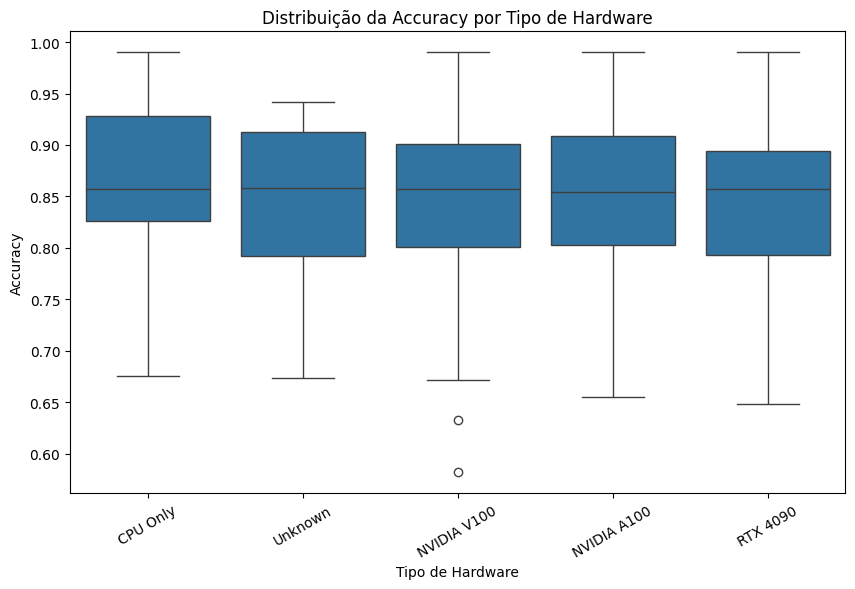

In [111]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="hardware_type",
    y="accuracy"
)

plt.title("Distribuição da Accuracy por Tipo de Hardware")
plt.xlabel("Tipo de Hardware")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

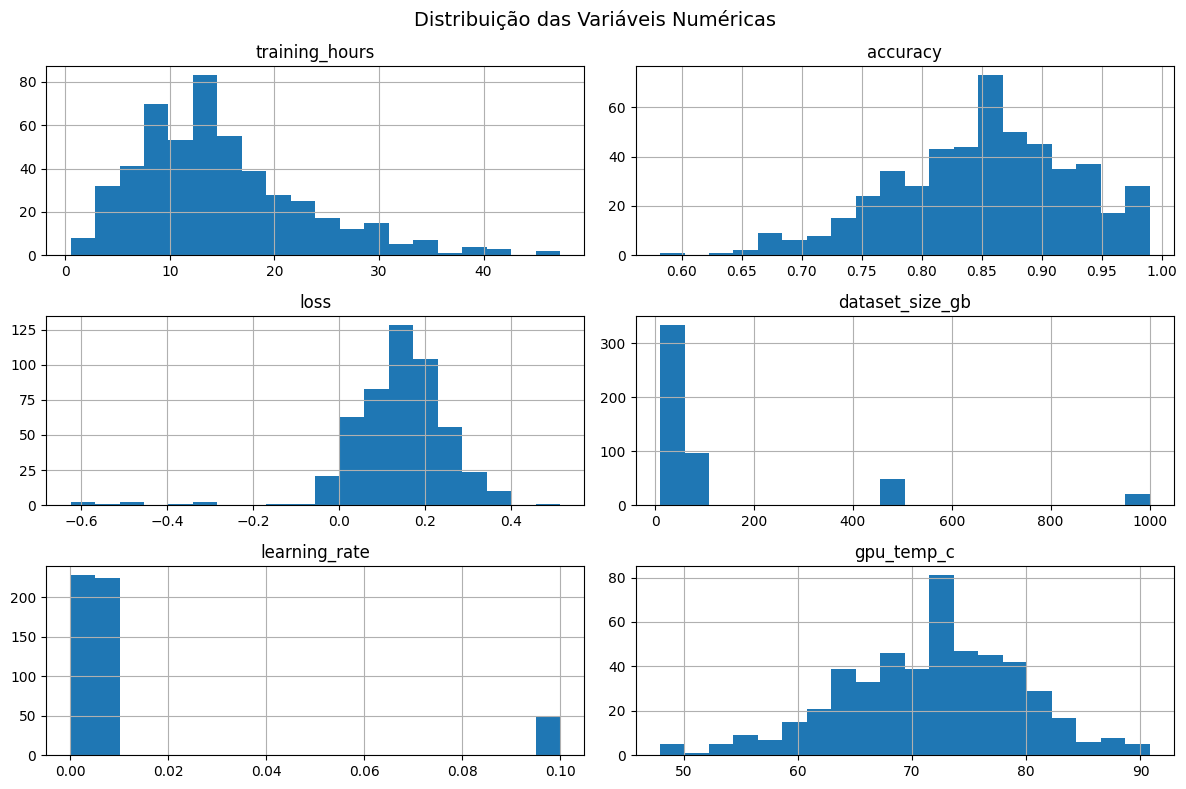

In [112]:
df[colunas_numericas].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle(
    "Distribuição das Variáveis Numéricas",
    fontsize=14
)

plt.tight_layout()
plt.show()

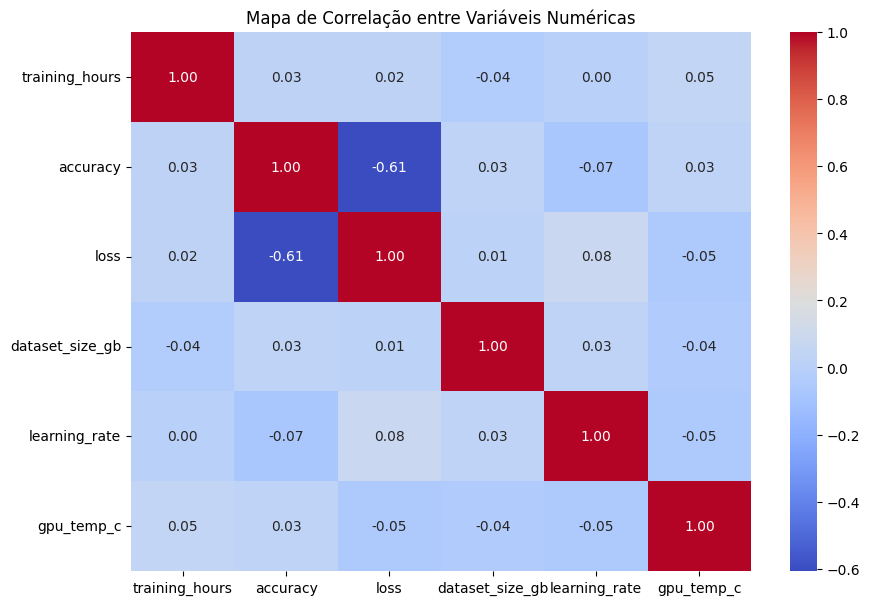

In [113]:
plt.figure(figsize=(10, 7))

correlacao = df[colunas_numericas].corr()

sns.heatmap(
    correlacao,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Mapa de Correlação entre Variáveis Numéricas")
plt.show()

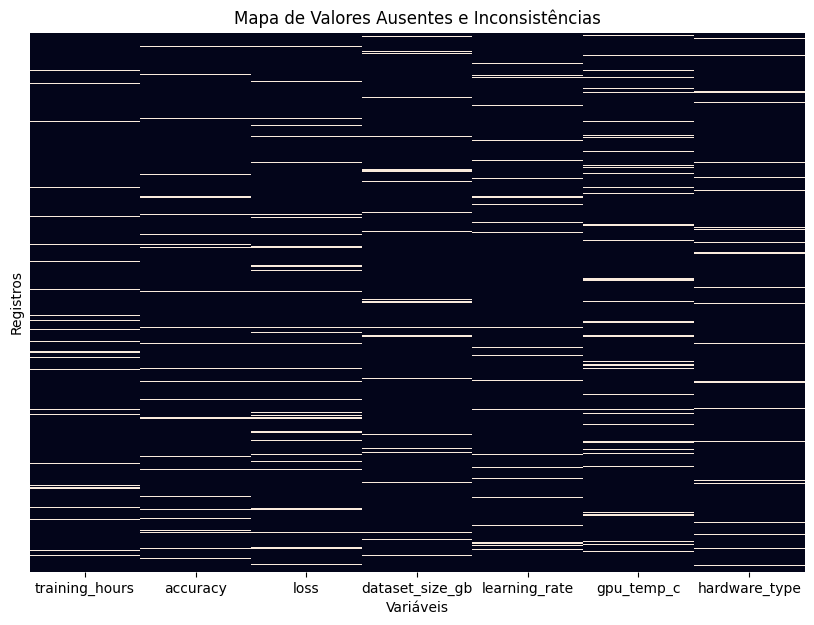

In [114]:
# Identificação de valores ausentes ou inconsistentes

ruido = pd.DataFrame(index=df_antes.index)

ruido["training_hours"] = df_antes["training_hours"].isnull()
ruido["accuracy"] = (
    df_antes["accuracy"].isnull() |
    (df_antes["accuracy"] > 1)
)
ruido["loss"] = df_antes["loss"].isnull()
ruido["dataset_size_gb"] = df_antes["dataset_size_gb"].isnull()
ruido["learning_rate"] = (
    df_antes["learning_rate"].isnull() |
    (df_antes["learning_rate"] < 0)
)
ruido["gpu_temp_c"] = (
    df_antes["gpu_temp_c"].isnull() |
    (df_antes["gpu_temp_c"] > 100)
)
ruido["hardware_type"] = df_antes["hardware_type"].isnull()

plt.figure(figsize=(10, 7))

sns.heatmap(
    ruido,
    cbar=False,
    yticklabels=False
)

plt.title("Mapa de Valores Ausentes e Inconsistências")
plt.xlabel("Variáveis")
plt.ylabel("Registros")
plt.show()

## 5. Storytelling dos Resultados

A análise exploratória realizada permitiu identificar padrões de comportamento, problemas de qualidade dos dados e relações entre as métricas dos experimentos de Machine Learning.

Os resultados obtidos nas etapas de limpeza, estatística descritiva, análise de outliers e visualização serão utilizados para interpretar o desempenho dos modelos e identificar possíveis impactos relacionados ao hardware, às métricas de treinamento e ao processo de deploy.

## 5.2 Deploy

In [115]:
desempenho_hardware = df.groupby("hardware_type")[
    ["accuracy", "loss", "gpu_temp_c"]
].agg(["mean", "median"])

desempenho_hardware

accuracy                loss           gpu_temp_c           
                   mean    median      mean    median       mean     median
hardware_type                                                              
CPU Only       0.867178  0.857169  0.116450  0.147375  70.761878  71.325603
NVIDIA A100    0.852334  0.854004  0.150217  0.152455  71.708644  72.238882
NVIDIA V100    0.849545  0.857169  0.143795  0.150891  71.364075  72.238882
RTX 4090       0.844829  0.857169  0.141972  0.150891  72.314975  72.238882
Unknown        0.843150  0.858179  0.143105  0.161639  71.471098  72.238882

In [116]:
deploy_hardware = pd.crosstab(
    df["hardware_type"],
    df["deployment_status"],
    normalize="index"
) * 100

deploy_hardware.round(2)

deployment_status,Approved,Pending,Rejected,Review
hardware_type,,,,
CPU Only,44.29,24.29,28.57,2.86
NVIDIA A100,38.89,26.98,29.37,4.76
NVIDIA V100,38.46,17.58,35.71,8.24
RTX 4090,39.13,20.65,29.35,10.87
Unknown,43.33,30.00,16.67,10.00


In [117]:
temperatura_deploy = df.groupby("deployment_status")[
    "gpu_temp_c"
].agg(["mean", "median", "min", "max"])

temperatura_deploy.round(2)

,mean,median,min,max
deployment_status,,,,
Approved,71.20,72.24,48.69,89.57
Pending,71.55,72.24,52.59,88.34
Rejected,72.18,72.24,47.94,90.79
Review,70.79,71.70,54.64,89.24


## 5.3 Conclusão

A análise exploratória mostrou que o dataset apresentava problemas de qualidade, como valores ausentes, valores inconsistentes e possíveis outliers. Os valores ausentes foram tratados utilizando a mediana para as variáveis numéricas e a moda para a variável categórica `hardware_type`. Também foram corrigidos valores inconsistentes de `accuracy`, `learning_rate` e `gpu_temp_c`.

Na comparação entre os hardwares, o CPU Only apresentou a maior acurácia média (0,867) e o menor loss médio (0,116). Entretanto, o dataset não possui informações de custo dos equipamentos, portanto não é possível determinar diretamente qual hardware apresenta o melhor custo-benefício. As proporções de aprovação no deploy também variaram entre os diferentes hardwares, mas os dados não permitem afirmar que o hardware seja o único fator responsável pelo resultado do deploy.

A análise das temperaturas mostrou médias próximas entre os diferentes status de deploy, variando de aproximadamente 70,79 °C a 72,18 °C. Dessa forma, não foi identificada uma relação clara entre a temperatura média da GPU e o status de deploy. Além disso, a análise de correlação mostrou uma relação negativa moderada entre `accuracy` e `loss` (-0,61), enquanto as demais variáveis apresentaram correlações próximas de zero.

Como principal aprendizado do processo, destaca-se a importância da etapa de limpeza antes da análise. O tratamento dos valores ausentes e inconsistentes permitiu trabalhar com dados mais confiáveis e evitar que registros corrompidos influenciassem as conclusões da análise.